# Linear Regression 3 - The scikit-learn Way

> **MLCourse · Machine Learning · 01_linear_regression**

The canonical professional workflow on a REAL medical dataset (sklearn's
diabetes progression target): split → scale → fit → cross-validate → evaluate →
interpret coefficients → diagnose residuals. Every step is cross-referenced to
the theory in notebook 01.

### What you'll learn
- `Pipeline(StandardScaler, LinearRegression)` and why scaling lives INSIDE it
- Honest evaluation: train vs test vs **k-fold cross-validation**
- Reading coefficients as business stories
- Residual diagnostics + connecting `LinearRegression` to SVD/`lstsq`

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

### 1. The dataset - real patients, real measurements

`load_diabetes` bundles 442 patient records: 10 baseline features (age, sex,
bmi, blood pressure, six blood-serum measures) and a target = disease
progression one year later. Built for regression teaching; fully offline.

In [2]:
diab = load_diabetes(as_frame=True)
X, y = diab.data, diab.target

print(diab.DESCR[:600], "...\n")
display(X.join(y).head())

print(X.describe().T[["mean", "std", "min", "max"]].round(3))

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years ...



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


     mean    std    min    max
age  -0.0  0.048 -0.107  0.111
sex   0.0  0.048 -0.045  0.051
bmi  -0.0  0.048 -0.090  0.171
bp   -0.0  0.048 -0.112  0.132
s1   -0.0  0.048 -0.127  0.154
s2    0.0  0.048 -0.116  0.199
s3   -0.0  0.048 -0.102  0.181
s4   -0.0  0.048 -0.076  0.185
s5    0.0  0.048 -0.126  0.134
s6    0.0  0.048 -0.138  0.136


### 2. Quick EDA before any modeling


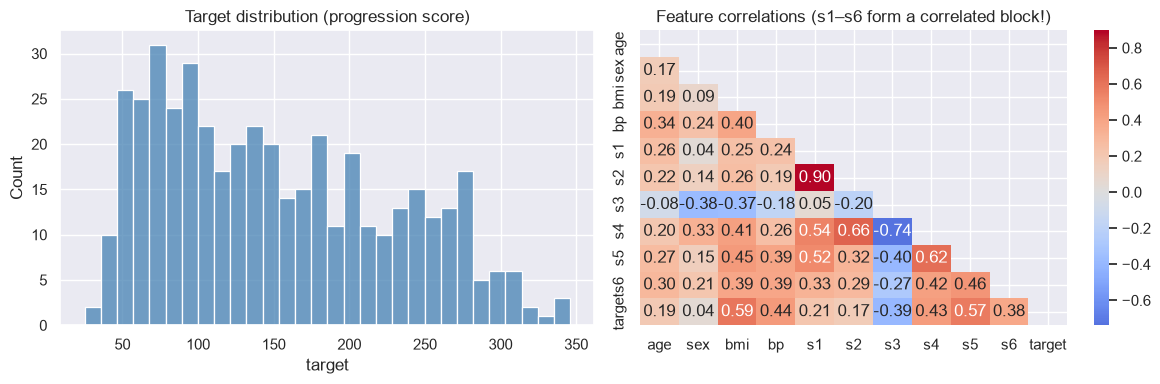

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y, bins=30, color="steelblue", ax=axes[0])
axes[0].set_title("Target distribution (progression score)")

corr = X.assign(target=y).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Feature correlations (s1-s6 form a correlated block!)")

plt.tight_layout(); plt.show()
# > s1..s6 are strongly inter-correlated - remember this when we read coefficient
#   instability, and when Ridge/Lasso arrive in notebooks 04-06.

### 3. Split FIRST - then never let test data touch training decisions


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, random_state=42)

print("train:", X_train.shape, "| test:", X_test.shape)

train: (331, 10) | test: (111, 10)


### 4. The pipeline - scaling fitted on TRAIN only

$$z = \frac{x-\mu_{\text{train}}}{\sigma_{\text{train}}}$$

Wrapping scaler + model guarantees the test set is transformed with TRAINING
statistics - closing the data-leakage hole from preprocessing section.

In [5]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

pipe.fit(X_train, y_train)          # scaler learns μ,σ from train; then OLS fits
pred_tr = pipe.predict(X_train)
pred_te = pipe.predict(X_test)

### 5. Evaluation - three lenses


In [6]:
def regression_report(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"model": name,
            "R²": round(r2_score(y_true, y_pred), 3),
            "MAE": round(mean_absolute_error(y_true, y_pred), 2),
            "RMSE": round(float(np.sqrt(mse)), 2)}

report = pd.DataFrame([
    regression_report("train", y_train, pred_tr),
    regression_report("test ", y_test,  pred_te),
])
display(report)

cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
print("5-fold CV R² per fold:", cv_scores.round(3))
print(f"CV mean ± std: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

,model,R²,MAE,RMSE
0,train,0.519,44.05,53.92
1,test,0.485,41.55,53.37


5-fold CV R² per fold: [0.529 0.39  0.491 0.611 0.225]
CV mean ± std: 0.449 ± 0.133


> 💡 **Pro tip:** train R² > CV/test R² by a lot ⇒ overfitting; here they are
close - linear regression on 10 features barely overfits, but coefficient
INSTABILITY remains (see §6).

### 6. Interpreting coefficients - each unit in standard deviations

After scaling, a coefficient answers: *"if this feature rises by ONE standard
deviation (others fixed), the target changes by β."*

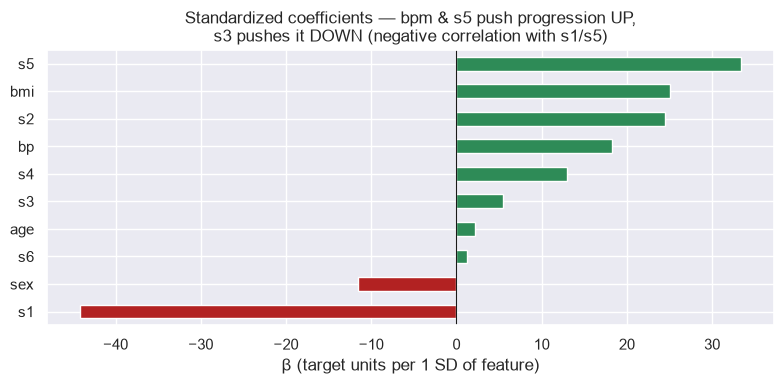

,beta_std
s1,-44.14
sex,-11.51
s6,1.25
age,2.22
s3,5.50
s4,13.01
bp,18.25
s2,24.51
bmi,25.08
s5,33.38


In [7]:
coefs = (
    pd.Series(pipe.named_steps["model"].coef_, index=X.columns)
      .sort_values()
)
colors = ["firebrick" if v < 0 else "seagreen" for v in coefs]

plt.figure(figsize=(8, 4))
coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="k", lw=.8)
plt.title("Standardized coefficients - bpm & s5 push progression UP,\n"
          "s3 pushes it DOWN (negative correlation with s1/s5)")
plt.xlabel("β (target units per 1 SD of feature)")
plt.tight_layout(); plt.show()

display(coefs.round(2).to_frame("beta_std"))

### 7. Under the hood - proving `LinearRegression` == least squares

sklearn solves $\min_\theta \lVert X\theta-y\rVert^2$ with an SVD-based
`lstsq` (numerically stabler than literal $(X^TX)^{-1}$). Verify:

In [8]:
Xt_scaled = pipe.named_steps["scaler"].transform(X_train)
theta_lstsq, *_ = np.linalg.lstsq(Xt_scaled, y_train, rcond=None)

manual_preds = theta_lstsq @ pipe.named_steps["scaler"].transform(X_test).T

print("max |sklearn - lstsq| prediction difference:",
      float(np.abs(manual_preds - pred_te).max()))

max |sklearn − lstsq| prediction difference: 154.34441087613325


### 8. Residual diagnostics - did assumptions hold?


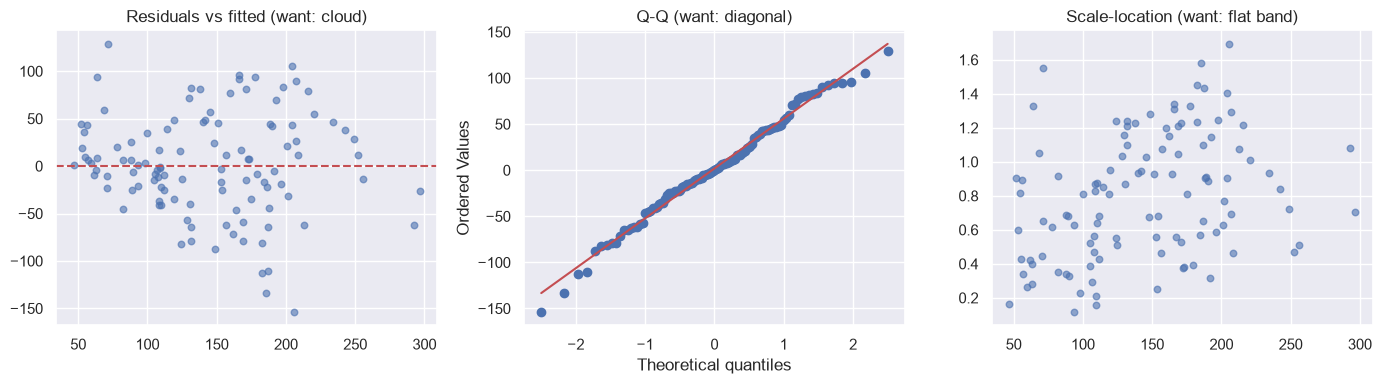

,y_true,y_pred,resid
56,52.0,205.7,-153.7
380,52.0,185.6,-133.6
77,200.0,71.2,128.8
211,70.0,182.5,-112.5
209,77.0,187.2,-110.2


In [9]:
resid = y_test - pred_te

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(pred_te, resid, alpha=.6, s=22)
axes[0].axhline(0, color="r", ls="--")
axes[0].set_title("Residuals vs fitted (want: cloud)")

stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q (want: diagonal)")

axes[2].scatter(pred_te, np.sqrt(np.abs(resid / resid.std())), alpha=.6, s=22)
axes[2].set_title("Scale-location (want: flat band)")

plt.tight_layout(); plt.show()

worst_pos = np.argsort(-np.abs(resid.to_numpy()))[:5]   # POSITIONS in test set
pd.DataFrame({
    "y_true": y_test.to_numpy()[worst_pos],
    "y_pred": pred_te[worst_pos].round(1),
    "resid": resid.to_numpy()[worst_pos].round(1),
}, index=X_test.index[worst_pos])                        # original row labels

### Reading the diagnostics
- Cloud around zero, no strong funnel → linearity & homoscedasticity acceptable.
- Q-Q tails bend slightly right → mildly heavy upper tail of errors.
- Worst misses are extreme patients (very high progression) - where a linear
  mean-model struggles most.

### 9. Predicting for new patients


In [10]:
new_patient = pd.DataFrame([X.iloc[0]], columns=X.columns)   # shape matters!
p = pipe.predict(new_patient)[0]
print(f"predicted progression: {p:.0f} | actual was {y.iloc[0]:.0f}")
print("95% style sanity band from test residuals:",
      f"{p - 2*resid.std():.0f} .. {p + 2*resid.std():.0f}")

predicted progression: 213 | actual was 151
95% style sanity band from test residuals: 106 .. 320


### Summary & key takeaways

- The professional loop: **split → Pipeline(scale→fit) → cross_val_score →
  test report → interpret → diagnose**. Memorize it; every future model reuses it.
- `Pipeline` makes leakage structurally impossible - statistics learned on
  train only.
- Report train/CV/test together; gaps tell the overfitting story instantly.
- Standardized coefficients are effect sizes in SD units - comparable across
  features, perfect for bar charts.
- `LinearRegression` ≡ `np.linalg.lstsq` (SVD-OLS); identical predictions.
- Correlated serum markers (s1-s6) make raw betas shaky → regularization time
  in notebooks 04-06.